# GPU repricing: concentrated or widespread?
**RTX 3090 rental quotes | Vast.ai, February–August 2026**

When GPU prices move unusually, is the change concentrated among a few hosts
or spread across the market? We study **magnitude, duration and breadth**.
A large renter could produce such a pattern; the model investigates the price
behaviour without assuming which workload caused it.

Figure 1 establishes the price movement and host participation. Figure 2
separates lower, median and upper price changes. We compare
price behaviour with a historical baseline, then inspect the records behind
the departure. The index keeps genuine price movements; the baseline helps
us interpret them.

## 1. Data and scope
The collector checked RTX 3090 rental listings every ten minutes: approximately
**144 searches per day**. We use a day only when at least **120 of those searches**
completed successfully and their saved records agree with the collection log.
This rejects days with too much missing collection; it does not establish that
the searches covered the whole market.

A **host** is the owner account offering the hardware for rent. One host can
list several **machines**, each identified by a machine ID. An **offer** is a
rental listing for that hardware. A machine ID can persist when its offer changes.

**Each search saved at most 64 offers.** Those were not necessarily the same
64 each time: the raw history contains 1,662 different machine IDs. However,
about 88% of successful searches reached that limit. The publisher does not
document the ordering, so we cannot assume these are the cheapest listings,
a random sample, or exactly the first page a website visitor would see.

We retain verified listings with reliability of at least 99% and valid recorded
hardware details. Matching and the fixed April group help us check price changes
in those records. **They do not recover the listings the collector missed.**
The figures therefore describe the collected sample, not all RTX 3090 capacity
on Vast.ai. The result limit and how listings were selected are the main data
limitations of this study.

Prices are the listing's recorded dollars per hour. The dataset does not give
the number of GPUs covered by each quote, so we cannot reliably convert every
listing to dollars per GPU-hour or separate one-GPU from eight-GPU rentals.

<details><summary><strong>Rental inference used for supporting context</strong></summary>

**Rental assumption.** We classify a machine as rented when its listing is
present in three consecutive snapshots with unchanged recorded attributes, then
absent for at least six hours of uninterrupted collection. The rental starts at
the first absent snapshot, at the last posted hourly rate. This is our inference
from listing history. The activity table calls these **inferred rental starts**.

The **rental price index** uses daily posted prices on the matched configurations;
rental start rates use the last price before each disappearance. These are
separate measures. Prices retain the source unit, USD/hour, because the dataset
omits GPU quantity. A new offer ID alone does not count as a rental.
Changes in search truncation prevent treating these counts as comparable measures
of market-wide rental demand. They remain a separate descriptive series.

</details>

In [1]:
from pathlib import Path
import hashlib, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML

ROOT=Path.cwd()
if not (ROOT/'daily_baseline.py').exists():ROOT=ROOT/'modelling'/'rtx3090'
sys.path.insert(0,str(ROOT))
from indices import clean_observations,select_segment,scan_market,daily_market
from daily_baseline import daily_quotes,chain_daily,fit_baseline,episodes,host_breadth,host_leave_one_out
from market_checks import (direct_reference,omit_hosts_from_chain,coverage_sensitivity,
    baseline_sensitivity,pre_event_holdout)
from rentals import infer_rentals,daily_rentals
from price_components import april_cohort,price_components,segment_coverage,percentile_sensitivity
from repricing import daily_transitions,transition_host_sensitivity,forecast_comparison
from component_diagnostics import (common_sample_transitions,selected_date_panel,
    observation_sensitivity,host_path_sensitivity)

DATA,OUT=ROOT.parent/'vast-market'/'data',ROOT/'outputs'/'daily'
CHECKS=OUT/'robustness'
OUT.mkdir(parents=True,exist_ok=True);CHECKS.mkdir(exist_ok=True)
BASE_DAY='2026-04-30'
def say(text):display(Markdown(text.replace('$','&#36;')))
def details_table(title,frame,formats=None):
    table=frame.style.hide(axis='index').format(formats or {},na_rep='Unavailable').to_html()
    display(HTML(f'<details><summary><strong>{title}</strong></summary>{table}</details>'))
def details_text(title,text):
    from html import escape
    display(HTML(f'<details><summary><strong>{title}</strong></summary><p>{escape(text.replace("**",""))}</p></details>'))

hashes={name:hashlib.sha256((DATA/name).read_bytes()).hexdigest()
        for name in ['snapshots.parquet','snapshot_meta.parquet']}
assert hashes==json.loads((DATA.parent/'input_hashes.json').read_text())
raw,meta=[pd.read_parquet(DATA/name) for name in hashes]
clean,scans,source_audit=clean_observations(raw,meta)
segment=select_segment(clean)
daily=daily_market(scan_market(segment,scans,budget=.20),minimum_scans=120)
quotes=daily_quotes(segment,daily)
index,pairs=chain_daily(quotes,daily,base_day=BASE_DAY)
assert index.matched_index.notna().all()
assert pairs.groupby(['day','machine_id']).size().eq(1).all()
rentals=infer_rentals(raw,segment,scans,hours=6)
rental_daily=daily_rentals(rentals,scans,daily,hours=6)
rental_rule_records=[]
for hours in [3,6,12]:
    classified=rentals if hours==6 else infer_rentals(raw,segment,scans,hours=hours)
    rental_rule_records.append(dict(absence_hours=hours,starts=len(classified),
        machines=classified.machine_id.nunique(),uncapped_starts=int(classified.uncapped_window.sum()),
        median_inferred_rate=float(classified.inferred_rental_rate.median())))
rental_rules=pd.DataFrame(rental_rule_records)
say(f"**Sample:** {len(index)} daily price observations, {index.index.min():%B %d}–{index.index.max():%B %d}. "
    f"Each daily price comparison includes {int(index.matched_machines.min())}–"
    f"{int(index.matched_machines.max())} machines.")

recorded_days=quotes.groupby('machine_id').day.nunique()
recorded_months=quotes.assign(month=quotes.day.dt.strftime('%Y-%m')).groupby('machine_id').month.nunique()
month_count=quotes.day.dt.strftime('%Y-%m').nunique()
say(f"Of {len(recorded_days)} qualifying machines, {int(recorded_months.eq(month_count).sum())} "
    f"appear in every calendar month. The longest record contains prices on "
    f"{int(recorded_days.max())} of {len(index)} days.")

**Sample:** 179 daily price observations, February 17–August 14. Each daily price comparison includes 29–210 machines.

Of 804 qualifying machines, 112 appear in every calendar month. The longest record contains prices on 176 of 179 days.

## 2. Price index and model calibration
**Matched-model price index.** For each machine configuration, calculate the daily
median quote and compare it with the preceding day's quote. Match on machine,
host, location, GPU memory, CPU cores and CPU memory. The geometric mean of
these price relatives forms each daily link. Chaining the links gives a
**Jevons index**, rebased to April 30 = 100. Comparing the same configurations
measures repricing within matched records. The set of records can still change
from one daily link to the next.

**Baseline.** Fit a robust exponential-smoothing model to the log index. March
calibrates the maximum residual used in each update; April selects the smoothing
half-life and sets the residual limits. Score each observation before updating
the model. From May onward, keep the parameters fixed and allow the level to adapt.

**Anomaly detection.** Flag periods with at least three consecutive days outside
the residual limits on the same side. Report the percentage deviation, duration
and proportion of hosts with higher quotes. The limits are April's empirical
residual range, not a calibrated probability interval.

<details><summary><strong>Model specification</strong></summary>

Figure 2 calculates lower and upper price changes within a fixed April cohort,
then fits each component separately. These are cross-sectional percentiles of
price relatives. They show whether large increases are confined to a few
listings or extend through the distribution.

Calculate each day's components from that day's prices and score against
the preceding model state. From May onward, no future prices enter a day's signal.

With $y_t=\log I_t$, the one-step estimate, residual and update are

$$\widehat y_t=\ell_{t-1},\qquad e_t=y_t-\widehat y_t,\qquad
\ell_t=\ell_{t-1}+\alpha\,\operatorname{clip}(e_t,-c,c).$$

For half-life $h$, $\alpha=1-2^{-1/h}$. The plotted percentage residual is
$100(I_t/\exp(\widehat y_t)-1)$. The price index is unchanged by the residual cap.

</details>

In [2]:
model,parameters,candidates=fit_baseline(index.matched_index)
events=episodes(model,minimum_days=3)
breadth,host_audit=host_breadth(quotes)
days=daily.reindex(index.index)
direct,direct_matches=direct_reference(quotes,index.index,BASE_DAY)
host_paths,host_path_audit=omit_hosts_from_chain(pairs,index,BASE_DAY)
complete_hosts=host_path_audit.loc[host_path_audit.complete,'excluded_host']
complete_paths=host_paths.loc[:,complete_hosts]
host_low,host_high=complete_paths.min(axis=1),complete_paths.max(axis=1)
coverage,coverage_links=coverage_sensitivity(quotes,daily,BASE_DAY)
sensitivity,agreement=baseline_sensitivity(index.matched_index,parameters,candidates)
holdout=pre_event_holdout(index.matched_index)
april_residual_correlation=model.loc['2026-04','residual'].autocorr()
core=agreement.index[agreement.eq(100)]
assert len(core)==(core.max()-core.min()).days+1
main_event=events.loc[events.peak_deviation_pct.idxmax()]
peak_day=model.observed.idxmax();peak=model.loc[peak_day];peak_hosts=breadth.loc[peak_day]
daily_change=100*np.expm1(index.log_change)
april_daily_change=daily_change.loc['2026-04'].abs()
return_day=main_event.end+pd.Timedelta(days=1)
return_level=model.loc[return_day];return_hosts=breadth.loc[return_day]
band_pct=100*np.expm1(parameters['width'])
say(f"The selected half-life is **{parameters['half_life']:.0f} days**. "
    f"April's residual limits are **−{100*(1-np.exp(-parameters['width'])):.2f}% to +{band_pct:.2f}%** "
    f"around the estimated level. April's median absolute daily price change is "
    f"**{april_daily_change.median():.2f}%**.")
say(f"The update cap limits the baseline's rise to **{100*np.expm1(parameters['alpha']*parameters['update_cap']):.3f}% "
    "per day** during a large shock. This keeps the reference from following the spike immediately. "
    "The April range is a historical reference, with no validated false-alarm rate.")

The selected half-life is **7 days**. April's residual limits are **−2.75% to +2.83%** around the estimated level. April's median absolute daily price change is **0.22%**.

The update cap limits the baseline's rise to **0.256% per day** during a large shock. This keeps the reference from following the spike immediately. The April range is a historical reference, with no validated false-alarm rate.

In [3]:
from charts import history_figure,distribution_figure

def save(fig,name,tight=False):
    options={'bbox_inches':'tight','pad_inches':.12} if tight else {}
    for ext in ['png','svg']:fig.savefig(OUT/f'{name}.{ext}',dpi=170,**options)
    display(fig);plt.close(fig)

## 3. Results: the May price increase
Read Figure 1 from top to bottom: **prices, deviation from the baseline,
then the share of hosts raising or lowering prices**. Blue is the rental price
index; orange is the baseline and April reference range. Blue shading marks
sustained positive deviations, red marks negative deviations, and gray marks
calibration. The bottom strip shows how many machines support each daily link.
All axes are linear.

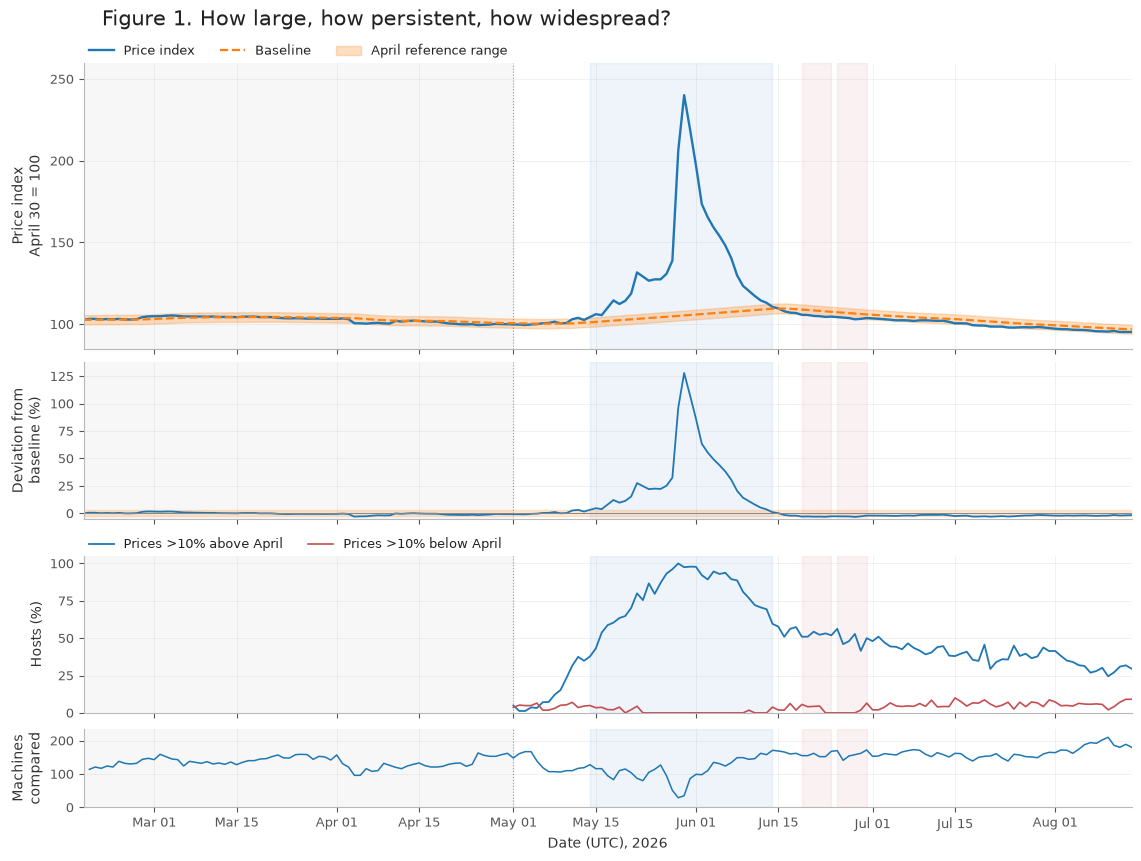

**Onset and duration.** The positive price anomaly runs from **May 14 to June 13**, lasting 31 days. The three-day rule confirms it on May 16.

**Price change.** The index peaks at **240.1 on May 30**, up 140.1% from April 30. The model estimate is 105.4, giving a relative residual of **+127.9%**. The matched-model index records changes in existing quotes. It describes the collected sample.

**Peak precision.** May 29 contributes a **48.4% daily rise** from 29 matches. Requiring two quotes per machine-day breaks the coverage rule there. On May 30, the equal-host index is 244.8 and the direct April 30 comparison is 287.9. The increase is substantial across methods; its exact size depends on the index definition and sample.

**Host repricing.** On May 30, **39 of 40 eligible hosts** quote more than 10% above their machines' April reference prices. The comparison includes 40 of 59 hosts observed that day. Each eligible host has one vote.

**Price correction.** By June 14, the index is **110.6** and the residual is back within the detection limits. Prices remain 10.6% above April 30; 31 of 52 eligible hosts still quote more than 10% above their April references. The anomaly has ended under the model's rule, while part of the repricing remains.

In [4]:
fig=history_figure(model,index,breadth,events,parameters)
save(fig,'01_daily_baseline',tight=True)
say(f"**Onset and duration.** The positive price anomaly runs from "
    f"**{main_event.start:%B %d} to {main_event.end:%B %d}**, lasting {int(main_event.days)} days. "
    f"The three-day rule confirms it on {main_event.confirmed:%B %d}.")
say(f"**Price change.** The index peaks at **{peak.observed:.1f} on {peak_day:%B %d}**, "
    f"up {peak.observed-100:.1f}% from April 30. The model estimate is {peak.baseline:.1f}, "
    f"giving a relative residual of **+{peak.deviation_pct:.1f}%**. "
    "The matched-model index records changes in existing quotes. It describes the collected sample.")
say(f"**Peak precision.** May 29 contributes a **{daily_change.loc['2026-05-29']:.1f}% daily rise** "
    f"from {int(index.loc['2026-05-29','matched_machines'])} matches. Requiring two quotes per "
    "machine-day breaks the coverage rule there. On May 30, the equal-host index is "
    f"{index.loc[peak_day,'equal_host_index']:.1f} and the direct April 30 comparison is "
    f"{direct.loc[peak_day,'direct_index']:.1f}. The increase is substantial across methods; "
    "its exact size depends on the index definition and sample.")
say(f"**Host repricing.** On {peak_day:%B %d}, **{int(peak_hosts.above_hosts)} of "
    f"{int(peak_hosts.reference_hosts)} eligible hosts** quote more than 10% above their machines' "
    f"April reference prices. The comparison includes {int(peak_hosts.reference_hosts)} of "
    f"{int(peak_hosts.all_observed_hosts)} hosts observed that day. Each eligible host has one vote.")
say(f"**Price correction.** By {return_day:%B %d}, the index is **{return_level.observed:.1f}** "
    f"and the residual is back within the detection limits. Prices remain "
    f"{return_level.observed-100:.1f}% above April 30; {int(return_hosts.above_hosts)} of "
    f"{int(return_hosts.reference_hosts)} eligible hosts still quote more than 10% above their "
    "April references. The anomaly has ended under the model's rule, while part of the repricing remains.")

## 4. Concentrated or widespread?
Keep the machines listed on at least five April days, using the same reference
rule as the host comparison. Freeze this cohort on April 30 and exclude later
entrants. Each configuration keeps its own April median price as the reference.
We do not require it to survive to August or fill in prices while it is absent.

Figure 2 separates the **lower change (10th percentile)**, **median change**
and **upper change (95th percentile)**. An upper increase with little movement
in the middle or lower end is concentrated. An increase reaching the median
and lower end is more widespread among the listings represented that day.

The lower and upper components each have their own historical baseline.
The median is shown against its April reference: its pre-May history is flat,
so it cannot support the same residual calibration.

**These are changes relative to each machine's April price.** They do not rank
machines by absolute cost. If the lower component rises, even machines near
the low end of the repricing distribution have become more expensive.

**Fixed April cohort:** 320 configurations on **308 machines from 128 hosts**. The cohort's price index reaches **225.4 on May 30**, up 125.4% from April 30. The increase remains after excluding machines that enter after April.

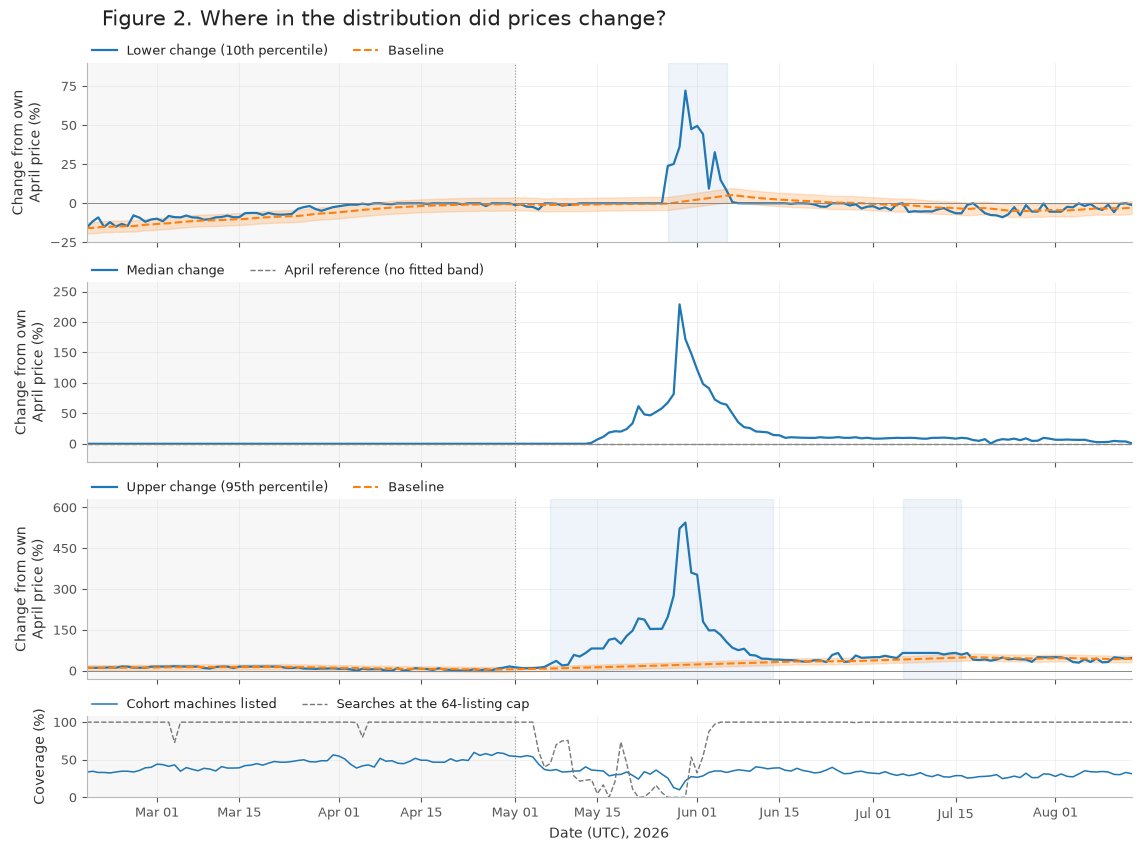

Date,Lower change (%),Median change (%),Upper change (%),Machines,Hosts above +10%
May 09,-1.4,+0.0,+19.6,104,9 / 59
May 16,+0.0,+11.4,+81.8,108,29 / 54
May 30,+72.1,+171.8,+544.5,68,39 / 40
Jun 14,+0.0,+14.4,+40.9,120,31 / 52


**The pattern.** On May 9 the median is unchanged from April, while the upper price change is about +20%; 9 of 59 eligible hosts are more than 10% above April. By May 30, the lower, median and upper changes are +72%, +172% and +544%, and 39 of 40 eligible hosts exceed +10%. The later increase is widespread within the listed April cohort. This is not just a handful of unusually expensive quotes.

**What is represented.** May 30 includes 68 of 308 cohort machines. The host denominator changes by date; on May 30 the reference covers 40 of 59 listed hosts. These are descriptive checkpoints, not a panel continuously observed between them. The three panels have different vertical scales; all show daily data.

**Check every daily transition.** We now compare each day's distribution with the preceding day using only configurations present at both endpoints. All 106 post-April transitions meet the primary 20-machine and 10-host gates. Every transition is also checked under stricter quote counts and with each host removed.

**Why matching matters.** From May 29 to May 30, the median in the full available distribution falls from +229.0% to +171.8% relative to April. Within that daily matched comparison (26 configurations, 19 hosts), the median instead rises from +229.0% to +269.0%. Changing listings can make the distribution look cheaper while existing quotes rise. That matched median increase stays positive after removing any contributing host.

...

**Sensitivity.** Requiring two daily quotes changes the May 30 lower/upper increases to +88%/+675%, preserving direction. Three or six quotes remove two under-covered days; both peak-spanning component episodes then confirm on June 1. Magnitudes and signal dates depend on coverage.

Quotes per machine-day,Valid days,May 30 machines,Lower change (%),Upper change (%)
1,179.000000,68.000000,+72.1,+544.5
2,179.000000,52.000000,+88.1,+675.1
3,177.000000,43.000000,+131.9,+804.3
6,177.000000,34.000000,+134.7,+833.4


before,after,percentile,listed_before,listed_after,Common configurations,common_hosts,All before,All after,Common before,Common after,Common daily change (%)
2026-05-06 00:00:00+00:00,2026-05-07 00:00:00+00:00,0.100000,114,110,86,44,100.000000,99.958726,100.000000,100.000000,0.093218
2026-05-06 00:00:00+00:00,2026-05-07 00:00:00+00:00,0.950000,114,110,86,44,114.000349,125.467359,112.820355,111.425618,0.093218
2026-05-26 00:00:00+00:00,2026-05-27 00:00:00+00:00,0.100000,95,79,66,37,100.000000,123.943184,111.712939,123.205546,3.490044
2026-05-26 00:00:00+00:00,2026-05-27 00:00:00+00:00,0.950000,95,79,66,37,254.077350,298.084432,284.734513,258.777361,3.490044


Segment,April configurations,April hosts,Valid daily links,Total links,Minimum machines,Minimum hosts
CA,77,34,97,178,3,2
US,85,39,144,178,11,6
US and Canada,162,73,175,178,14,8
April: at least 1 days,433,165,178,178,21,14
April: at least 5 days,320,128,178,178,20,13
April: at least 10 days,218,103,177,178,17,11
April: at least 15 days,132,67,177,178,14,8
April: at least 20 days,82,44,175,178,13,8


Percentile,May 30 change (%),Episode starts,Confirmed,Episode ends
10,+72.1,2026-05-27,2026-05-29,2026-06-05
20,+121.5,2026-05-22,2026-05-24,2026-06-08
80,+359.4,2026-05-05,2026-05-07,2026-07-27
90,+497.2,2026-05-07,2026-05-09,2026-06-11
95,+544.5,2026-05-07,2026-05-09,2026-06-13


In [5]:
cohort=april_cohort(quotes)
cohort_quotes=quotes[quotes.configuration.isin(cohort.configuration)]
cohort_index,cohort_pairs=chain_daily(cohort_quotes,daily,base_day=BASE_DAY)
components,component_rows=price_components(quotes,cohort,index.index)
segment_audit=segment_coverage(quotes,pairs,index.index)
component_checks=percentile_sensitivity(component_rows,components)
transition_checks=common_sample_transitions(component_rows,[
    ('2026-05-06','2026-05-07'),('2026-05-26','2026-05-27')])
panel_summary,panel_rows=selected_date_panel(component_rows,
    ['2026-05-07','2026-05-27','2026-05-30'])
component_observation_checks=observation_sensitivity(component_rows,index.index)
component_host_paths=host_path_sensitivity(component_rows,index.index)
all_transitions=daily_transitions(component_rows,index.index)
transition_omissions,transition_omission_paths=transition_host_sensitivity(component_rows,index.index)
transition_quote_checks=pd.concat([daily_transitions(component_rows,index.index,minimum_observations=n)
    .assign(minimum_observations=n) for n in [1,2,3,6]],ignore_index=True)
forecast_paths,forecast_scores,forecast_parameters=forecast_comparison(components)
host_confirmation_ranges=component_host_paths.groupby('component').agg(
    first=('confirmed','min'),last=('confirmed','max'),runs=('excluded_host','size'),
    successful=('status',lambda s:s.eq('calibrated').sum()))
assert cohort_index.matched_index.notna().all()
assert components.eligible.all()
assert cohort.reference_last.lt(pd.Timestamp('2026-05-01',tz='UTC')).all()
component_models={};component_parameters={};component_events=[]
for name in ['lower','upper']:
    fitted,params,_=fit_baseline(components[name])
    component_models[name]=fitted;component_parameters[name]=params
    component_events.append(episodes(fitted).assign(component=name))
component_events=pd.concat(component_events,ignore_index=True)
may_components=component_events[component_events.direction.eq('Above')&
    component_events.start.le(peak_day)&component_events.end.ge(peak_day)].set_index('component')
cohort_peak=cohort_index.matched_index.idxmax()
peak_components=components.loc[peak_day]
complete_configs=int(quotes.groupby('configuration').day.nunique().eq(len(index)).sum())
cohort_machines=cohort.machine_id.nunique();cohort_hosts=cohort.host_id.nunique()
tail_host_checks=[]
peak_rows=component_rows[component_rows.day.eq(peak_day)]
for host in peak_rows.host_id.unique():
    rest=peak_rows[peak_rows.host_id.ne(host)].relative
    tail_host_checks.append(dict(excluded_host=int(host),lower=float(rest.quantile(.1)),
        upper=float(rest.quantile(.95)),machines=len(rest)))
tail_host_checks=pd.DataFrame(tail_host_checks)
say(f"**Fixed April cohort:** {len(cohort)} configurations on **{cohort_machines} machines "
    f"from {cohort_hosts} hosts**. The cohort's price index reaches "
    f"**{cohort_index.loc[cohort_peak,'matched_index']:.1f} on {cohort_peak:%B %d}**, "
    f"up {cohort_index.loc[cohort_peak,'matched_index']-100:.1f}% from April 30. "
    "The increase remains after excluding machines that enter after April.")
fig=distribution_figure(components,component_models,component_events,days)
save(fig,'02_price_components',tight=True)

# Dates are fixed descriptive checkpoints: upper signal, index confirmation, index peak, return inside range.
checkpoint_dates=pd.DatetimeIndex([may_components.loc['upper','confirmed'],main_event.confirmed,
                                  peak_day,return_day])
checkpoints=components.loc[checkpoint_dates,['lower','median','upper','machines']].copy()
checkpoints[['lower','median','upper']]-=100
checkpoints['Hosts above +10%']=[f"{int(breadth.loc[d,'above_hosts'])} / {int(breadth.loc[d,'reference_hosts'])}"
                                for d in checkpoint_dates]
checkpoints.insert(0,'Date',checkpoint_dates.strftime('%b %d'))
display(checkpoints.rename(columns={'lower':'Lower change (%)','median':'Median change (%)',
    'upper':'Upper change (%)','machines':'Machines'}).style.hide(axis='index').format({
        'Lower change (%)':'{:+.1f}','Median change (%)':'{:+.1f}','Upper change (%)':'{:+.1f}',
        'Machines':'{:.0f}'}))
say("**The pattern.** On May 9 the median is unchanged from April, while the upper "
    "price change is about +20%; 9 of 59 eligible hosts are more than 10% above April. "
    "By May 30, the lower, median and upper changes are +72%, +172% and +544%, "
    "and 39 of 40 eligible hosts exceed +10%. The later increase is widespread within "
    "the listed April cohort. This is not just a handful of unusually expensive quotes.")
say(f"**What is represented.** May 30 includes {int(peak_components.machines)} of "
    f"{cohort_machines} cohort machines. The host denominator changes by date; on May 30 "
    f"the reference covers {int(peak_hosts.reference_hosts)} of {int(peak_hosts.all_observed_hosts)} "
    "listed hosts. These are descriptive checkpoints, not a panel continuously observed "
    "between them. The three panels have different vertical scales; all show daily data.")

post_transitions=all_transitions[all_transitions.day.ge('2026-05-01')]
transition_counts=post_transitions.groupby('percentile').eligible.agg(['sum','size'])
assert transition_counts['sum'].eq(106).all()
say("**Check every daily transition.** We now compare each day's distribution with "
    "the preceding day using only configurations present at both endpoints. All 106 "
    "post-April transitions meet the primary 20-machine and 10-host gates. "
    "Every transition is also checked under stricter quote counts and with each host removed.")
peak_transition=all_transitions[all_transitions.day.eq(peak_day)&all_transitions.percentile.eq(.5)].iloc[0]
median_omissions=transition_omissions[transition_omissions.day.eq(peak_day)&transition_omissions.percentile.eq(.5)].iloc[0]
say(f"**Why matching matters.** From May 29 to May 30, the median in the full available "
    f"distribution falls from +{peak_transition.visible_before-100:.1f}% to "
    f"+{peak_transition.visible_after-100:.1f}% relative to April. Within that daily matched "
    f"comparison ({int(peak_transition.matched_machines)} configurations, "
    f"{int(peak_transition.matched_hosts)} hosts), the median instead rises from "
    f"+{peak_transition.matched_before-100:.1f}% to +{peak_transition.matched_after-100:.1f}%. "
    "Changing listings can make the distribution look cheaper while existing quotes rise. "
    "That matched median increase stays positive after removing any contributing host.")
say("The matched quantile movements are changes in percentage points, not another chained "
    "index. They check the price distribution on common records; they do not recover prices "
    "of machines that are absent. [Full daily comparisons](outputs/daily/robustness/daily_repricing_transitions.csv).")
repeated_transitions=transition_quote_checks[
    transition_quote_checks.minimum_observations.eq(2)&transition_quote_checks.percentile.eq(.5)&
    transition_quote_checks.day.ge('2026-05-01')]
failed_transitions=repeated_transitions.loc[~repeated_transitions.eligible,'day']
say(f"**Quote coverage.** Requiring two quotes on each side retains "
    f"{int(repeated_transitions.eligible.sum())} of {len(repeated_transitions)} daily comparisons. "
    f"The missing comparisons are {', '.join(failed_transitions.dt.strftime('%b %d'))}. "
    "The May 30 example therefore depends on the primary quote rule; the stricter "
    "comparison cannot be published under the existing coverage gate.")
upper_transition=transition_checks[transition_checks.before.eq('2026-05-06')&transition_checks.percentile.eq(.95)].iloc[0]
lower_transition=transition_checks[transition_checks.before.eq('2026-05-26')&transition_checks.percentile.eq(.1)].iloc[0]
details_text("Earlier onset checks",f"On May 6–7, the upper percentile rises from "
    f"{upper_transition.all_before-100:.1f}% to {upper_transition.all_after-100:.1f}% above April. "
    f"Among the **{int(upper_transition.common_machines)} configurations present on both days**, "
    f"it falls from {upper_transition.common_before-100:.1f}% to {upper_transition.common_after-100:.1f}%. "
    "Changing visibility contributes to the early signal. At the lower component's May 26–27 "
    f"onset, the common-sample increase is {lower_transition.common_before-100:.1f}% to "
    f"{lower_transition.common_after-100:.1f}%: there is within-machine repricing as well.")
panel_display=panel_summary.copy()
panel_display['day']=panel_display.day.dt.strftime('%b %d')
for name in ['lower','median','upper']:panel_display[name]-=100
details_table('Earlier selected-date case study',panel_display[['day','machines','lower','median','upper']]
    .rename(columns={'day':'Date','machines':'Configurations','lower':'Lower change (%)',
    'median':'Median change (%)','upper':'Upper change (%)'}),
    {'Lower change (%)':'{:+.1f}','Median change (%)':'{:+.1f}','Upper change (%)':'{:+.1f}'})
obs_display=component_observation_checks.pivot(index='minimum_observations',columns='component',
    values=['peak_increase_pct','valid_days','peak_machines','peak_hosts'])
obs_table=pd.DataFrame({'Quotes per machine-day':obs_display.index,
    'Valid days':obs_display[('valid_days','lower')].to_numpy(),
    'May 30 machines':obs_display[('peak_machines','lower')].to_numpy(),
    'Lower change (%)':obs_display[('peak_increase_pct','lower')].to_numpy(),
    'Upper change (%)':obs_display[('peak_increase_pct','upper')].to_numpy()})
say("**Sensitivity.** Requiring two daily quotes changes the May 30 lower/upper "
    "increases to +88%/+675%, preserving direction. Three or six quotes remove two "
    "under-covered days; both peak-spanning component episodes then confirm on June 1. "
    "Magnitudes and signal dates depend on coverage.")
details_text('Coverage failures in the daily omission checks',
    "On May 29 the April-cohort comparison has exactly 20 configurations from 13 hosts. "
    "Removing any of those contributing hosts fails the 20-machine gate, leaving 13 "
    "unavailable omission results. Omitting a host absent from that pair leaves its "
    "result unchanged. May 30 has 26 configurations from 19 hosts and retains coverage "
    "when any contributing host is omitted. Full-path exports retain all failed gates.")
details_table('Quote-count sensitivity, with April membership and references held fixed' ,obs_table,
    {'Lower change (%)':'{:+.1f}','Upper change (%)':'{:+.1f}'})
details_table('Matched-model checks at component onset',transition_checks.rename(columns={
    'common_machines':'Common configurations','all_before':'All before','all_after':'All after',
    'common_before':'Common before','common_after':'Common after','common_change_pct':'Common daily change (%)'}))
details_table('Segment coverage: geography and fixed April cohorts',segment_audit[
    segment_audit.segment.isin(['US','CA','US and Canada','April: at least 1 days',
        'April: at least 5 days','April: at least 10 days','April: at least 15 days','April: at least 20 days'])]
    [['segment','april_configurations','april_hosts','supported_links','total_links','minimum_machines','minimum_hosts']]
    .rename(columns={'segment':'Segment','april_configurations':'April configurations',
        'april_hosts':'April hosts','supported_links':'Valid daily links','total_links':'Total links',
        'minimum_machines':'Minimum machines','minimum_hosts':'Minimum hosts'}))
details_table('Lower and upper components: percentile sensitivity',component_checks[
    ['percentile','anchor_level','start','confirmed','end']].assign(
    percentile=lambda d:(100*d.percentile).astype(int),anchor_level=lambda d:d.anchor_level-100)
    .rename(columns={'percentile':'Percentile','anchor_level':'May 30 change (%)',
        'start':'Episode starts','confirmed':'Confirmed','end':'Episode ends'}),{'May 30 change (%)':'{:+.1f}'})
details_text('Cohort selection and geographical coverage',f"No configuration appears on all {len(index)} days. "
    "A fully balanced panel would therefore be empty. The April cohort has "
    f"{int(components.machines.min())}–{int(components.machines.max())} machines per day's component calculation. "
    "The US and Canada separately, and together, fail the existing 20-machine and 10-host "
    "daily-link requirements near the peak. The all-region April cohort preserves every link; "
    f"its thinnest has {int(cohort_index.matched_machines.min())} machines and "
    f"{int(cohort_index.loc[cohort_index.matched_machines.idxmin(),'matched_hosts'])} hosts. "
    "The five-day rule reuses the existing host-reference rule, rather than choosing a segment "
    "because its price increase is large.")

activity=rental_daily.reindex(index.index)
april_activity=activity.loc['2026-04']
event_activity=activity.loc[main_event.start:main_event.end]
rental_period_records=[]
for label,start,end in [('April','2026-04-01','2026-04-30'),
    ('May 14–June 13',str(main_event.start.date()),str(main_event.end.date()))]:
    period=activity.loc[start:end]
    eligible_days=period.index[period.publish.fillna(False)]
    selected_events=rentals[rentals.day.isin(eligible_days)]
    rental_period_records.append({'Period':label,'Inferred starts':len(selected_events),
        'Starts per day':period.rental_starts.mean(),
        'Wholly uncapped events':int(selected_events.uncapped_window.sum()),
        'Searches capped (%)':100*days.loc[start:end].capped_share.mean()})
rental_periods=pd.DataFrame(rental_period_records)

## 5. Does a more complex baseline help?
We tested a small regression of each log component on its previous day's value
and a weekend indicator, with coefficients fitted through April 30. It competes
with yesterday's value and the existing EWMA. This predicts a daily summary;
it is not machine-level conditional quantile regression. Forecast accuracy and
sustained-departure monitoring are different objectives.

In [6]:
forecast_overall=forecast_scores[forecast_scores.period.eq('All evaluation dates')]
details_table('Forecast replay: May 1 through August 14',forecast_overall[
    ['component','model','days','rms_log_pct']].rename(columns={'component':'Component','model':'Model',
    'days':'Scored days','rms_log_pct':'RMS log error (×100)'}),{'RMS log error (×100)':'{:.2f}'})
say("The lag-and-weekend regression slightly improves the lower component's forecast "
    "over yesterday's value, but is worse for the upper component. It does not provide a "
    "consistent improvement. We retain the existing slow baseline for studying sustained "
    "departures, and do not present it as the best next-day forecaster. The median's flat "
    "training history cannot identify the regression or the EWMA residual band.")
say("This is chronological historical replay. The period has already informed the study, "
    "so it is not an untouched validation set. Neither model has a validated false-alarm rate.")

comparison=pd.DataFrame({
    'Price index':['Chained Jevons','Equal-host chain','Direct April 30 Jevons'],
    f'{peak_day:%B %d}':[peak.observed,index.loc[peak_day,'equal_host_index'],direct.loc[peak_day,'direct_index']],
    f'{index.index.max():%B %d}':[model.observed.iloc[-1],index.equal_host_index.iloc[-1],direct.direct_index.iloc[-1]]})
details_table('Alternative price indices',comparison,{c:'{:.1f}' for c in comparison.columns[1:]})
details_text('Index construction and host influence',f"All three indices show the price increase and subsequent correction. Their August levels "
    "differ because the chain matches adjacent days while the direct index matches survivors "
    f"against April 30. Excluding each host from the entire chain gives May 30 levels of "
    f"**{host_low.loc[peak_day]:.1f}–{host_high.loc[peak_day]:.1f}**; "
    f"all {len(complete_hosts)} recalculated series retain coverage.")
details_text('Baseline parameter sensitivity',f"Across {len(sensitivity)} combinations of smoothing half-life, update cap, residual quantile "
    f"and minimum duration, the main anomaly lasts **{sensitivity.days.min()}–{sensitivity.days.max()} days**. "
    f"Every specification includes {core.min():%B %d}–{core.max():%B %d}.")
details_text('Percentile choices and peak concentration',"The cohort component sequence also survives nearby percentile choices: the upper "
    "80th–95th percentiles confirm on May 7–9, while the lower 10th–20th percentiles "
    "confirm on May 24–29. These dates use independently calibrated component baselines. "
    "Episode endings are more sensitive: the upper 80th percentile remains outside its "
    "narrow reference range until July 27, versus June 13 for the 95th percentile. "
    f"Removing one host at a time on May 30 leaves the 10th-percentile increase at "
    f"{tail_host_checks.lower.min()-100:.1f}%–{tail_host_checks.lower.max()-100:.1f}%, "
    f"and the 95th-percentile increase at {tail_host_checks.upper.min()-100:.1f}%–"
    f"{tail_host_checks.upper.max()-100:.1f}%. This checks the distribution that day, not "
    "the sensitivity of each component's entire modeled path.")
assert component_host_paths.status.eq('calibrated').all()
host_date_pairs=component_host_paths.pivot(index='excluded_host',columns='component',values='confirmed')
assert host_date_pairs.upper.lt(host_date_pairs.lower).all()
details_text("Host influence on component signals",f"Removing each of {int(host_confirmation_ranges.loc['upper','runs'])} hosts "
    "from the entire component history and recalibrating preserves the upper-before-lower "
    f"ordering. Upper confirmations range from {host_confirmation_ranges.loc['upper','first']:%B %d} "
    f"to {host_confirmation_ranges.loc['upper','last']:%B %d}; lower confirmations range from "
    f"{host_confirmation_ranges.loc['lower','first']:%B %d} to "
    f"{host_confirmation_ranges.loc['lower','last']:%B %d}. Exact dates are sensitive to sample membership.")
thin_day=index.matched_machines.idxmin();thin_pairs=pairs[pairs.day.eq(thin_day)]
repeated=thin_pairs[thin_pairs.observations.ge(2)&thin_pairs.previous_observations.ge(2)]
leave_out=host_leave_one_out(pairs,str(thin_day.date()))
checks=pd.DataFrame([
    {'Sample':'All matches','Machines':len(thin_pairs),'Hosts':thin_pairs.host_id.nunique(),
     'Daily change (%)':100*np.expm1(thin_pairs.log_change.mean())},
    {'Sample':'Two observations per machine-day','Machines':len(repeated),'Hosts':repeated.host_id.nunique(),
     'Daily change (%)':100*np.expm1(repeated.log_change.mean())}])
details_text('The thinnest price-index link',f"The smallest sample occurs on {thin_day:%B %d}: "
    f"{len(thin_pairs)} machines and {thin_pairs.host_id.nunique()} hosts, with a "
    f"{daily_change.loc[thin_day]:.1f}% daily increase. Requiring two observations per "
    f"machine-day leaves {len(repeated)} machines, below the 20-machine minimum. "
    "The stricter index stops at that date.")
details_table('Quote coverage on May 29',checks,{'Daily change (%)':'{:+.1f}'})
details_table('Rental identification: duration sensitivity',rental_rules.rename(columns={
    'absence_hours':'Minimum absence (hours)','starts':'Rental starts','machines':'Machines',
    'uncapped_starts':'Uncapped windows','median_inferred_rate':'Median rental rate (USD/hour)'}),
    {'Median rental rate (USD/hour)':'{:.4f}'})
coverage_display=coverage[['minimum_observations','supported_links','total_links','first_break']].copy()
coverage_display['first_break']=coverage_display.first_break.fillna('None')
details_table('Full-history quote coverage',coverage_display.rename(columns={
    'minimum_observations':'Observations per machine-day','supported_links':'Valid links',
    'total_links':'Attempted links','first_break':'First break'}))
cap_table=sensitivity[sensitivity.half_life.eq(parameters['half_life'])&
    sensitivity['quantile'].eq(.95)&sensitivity.persistence_days.eq(3)]
details_table('Sensitivity to the baseline update cap',cap_table[['cap_multiplier','start','end','days']]
    .rename(columns={'cap_multiplier':'Cap multiplier','start':'From','end':'Through','days':'Days'}))
details_table('Model validation',pd.DataFrame([
    {'Check':'April residual autocorrelation, lag 1','Result':f'{april_residual_correlation:.2f}'},
    {'Check':'April 21–30 holdout','Result':f"{holdout['outside_days']} of {holdout['days']} days outside residual limits"},
    {'Check':'Holdout calibration','Result':'March cap; April 1–20 selects memory and residual limits'}]))
details_table('Rental inference retained as separate context',rental_periods[
    ['Period','Inferred starts','Wholly uncapped events','Searches capped (%)']],{'Searches capped (%)':'{:.1f}'})

Component,Model,Scored days,RMS log error (×100)
lower,EWMA,106,9.68
lower,Lag and weekend,106,5.35
lower,Persistence,106,5.51
median,Persistence,106,7.23
upper,EWMA,106,44.36
upper,Lag and weekend,106,15.21
upper,Persistence,106,10.75


The lag-and-weekend regression slightly improves the lower component's forecast over yesterday's value, but is worse for the upper component. It does not provide a consistent improvement. We retain the existing slow baseline for studying sustained departures, and do not present it as the best next-day forecaster. The median's flat training history cannot identify the regression or the EWMA residual band.

This is chronological historical replay. The period has already informed the study, so it is not an untouched validation set. Neither model has a validated false-alarm rate.

Price index,May 30,August 14
Chained Jevons,240.1,95.2
Equal-host chain,244.8,90.3
Direct April 30 Jevons,287.9,106.0


Sample,Machines,Hosts,Daily change (%)
All matches,29,17,+48.4
Two observations per machine-day,18,12,+49.7


Minimum absence (hours),Rental starts,Machines,Uncapped windows,Median rental rate (USD/hour)
3,3223,521,289,0.1708
6,1896,452,144,0.1714
12,1107,359,60,0.1748


Observations per machine-day,Valid links,Attempted links,First break
1,178,178,None
2,177,178,2026-05-29
3,176,178,2026-05-28
6,175,178,2026-05-28


Cap multiplier,From,Through,Days
0.5,2026-05-14,2026-06-15,33
1.0,2026-05-14,2026-06-13,31
2.0,2026-05-14,2026-06-10,28
uncapped,2026-05-14,2026-06-05,23


Check,Result
"April residual autocorrelation, lag 1",0.73
April 21–30 holdout,0 of 10 days outside residual limits
Holdout calibration,March cap; April 1–20 selects memory and residual limits


Period,Inferred starts,Wholly uncapped events,Searches capped (%)
April,341,0,99.3
May 14–June 13,364,116,46.8


## 6. What this study establishes
**The May increase became widespread within the listed April cohort.** The
median and lower price changes rose, host participation expanded, and daily
matched-model comparisons confirm substantial repricing. The index's large
departure from its historical baseline persisted for about a month.

**Changing availability also changes the apparent distribution.** The full
daily checks expose cases where listing turnover alters the direction of a
percentile movement. We can describe the progression from concentrated to
widespread increases in the collected sample; we cannot infer the exact
chronology for hosts while their machines are absent.

This is the research focus: **unusual price behaviour, its duration and its
breadth across hosts**. A large renter or mining workload is a possible
explanation to investigate separately. Price and listing history alone do not
identify the workload or establish how many bookings it generated.

The price index keeps real price changes. The baseline is a reference for
assessing their magnitude and persistence; seller participation shows breadth.

<details><summary><strong>Data limitations</strong></summary>

The source caps searches at 64 listings and does not record their ranking.
In April, 99% of scans hit that cap, versus 36% in May. Absence can therefore
also reflect search truncation, delisting or downtime. The rental interpretation
is the study's explicit identification assumption, not a verified transaction label.
Each full-machine absence counts once; partial rentals and repeated bookings
while a machine remains absent are not separately identified.

Daily matching changes the sample over time. The source omits GPU quantity
and some contract terms. Counts are listing events, not GPU units or total
marketplace bookings. No rentals or prices are imputed outside observed coverage.
The fixed cohort is selected using April information, so February–April are
retrospective calibration context. May–August use only previously known membership
and reference prices. No machine has an uninterrupted 179-day price record.
At least 20 machines and 10 hosts are required for cohort components; the upper
percentile is sensitive to a small number of machines, especially on thin days.
Matching controls recorded configuration fields; GPU quantity, contract terms
and other service attributes are not fully held constant.

The baseline is calibrated on a short history with serially correlated errors.
The ten-day holdout is insufficient to establish false-alarm rates. The study
was designed after observing May, so it is a retrospective case study. The
model identifies an unusual period; causal attribution requires additional data.

</details>

<details><summary><strong>Technical methods and reproduction</strong></summary>

**Index.** Hash-check source files; validate snapshot metadata and quote values.
Retain verified listings with reliability ≥99%, positive CPU cores and RAM.
Require ≥120 valid snapshots per day. Form per-configuration daily median prices,
then match consecutive calendar days on machine, host, country, region, GPU RAM,
CPU cores and CPU RAM. Remove machines with multiple matching configurations
within a daily pair. Require ≥20 matched machines and ≥10 hosts. Average log
price relatives, accumulate and rebase to April 30 = 100. Missing links break
the chain. The equal-host variant first averages within hosts. The direct index
uses the same match rules against April 30, with changing survivors.

**Calibration.** February initializes the level. For half-lives of 7, 14 and 28
days, use March's uncapped smoothing residuals to set the update cap to the
larger of three robust MAD scales or the 95th percentile absolute residual.
Select half-life by April mean absolute log error. Use April's 95th percentile
absolute log residual for symmetric log limits. Score each new day before the
update; parameters remain fixed after April. A three-day consecutive run
determines each anomaly, with confirmation on day three.

**Host repricing.** A configuration needs at least five observed April days.
Compare its current quote with its April median. Take the median log relative
within each host, then count hosts above +10% or below −10%. The denominator
is the eligible host sample for that day. It changes through time.

**Price components and fixed cohort.** Keep configurations appearing on at least
five April days. Freeze membership and each configuration's April median price
before May. For each calendar day, exclude machines represented by multiple
eligible configurations, then calculate 100 times price divided by own April
reference. Take the 10th, 50th and 95th percentiles with equal machine weights.
Require at least 20 machines and 10 hosts that day. Fit the historical baseline
separately to the lower and upper components. Percentiles
across machines describe heterogeneity in repricing. They are not the empirical
residual limits around each baseline, and are not absolute cheap/expensive tiers.
The median is retained descriptively; its March level is flat and provides no
variation for the current residual-cap calibration.

Rebuild the same daily Jevons chain using only cohort configurations. Retain
the existing daily-link coverage requirements without bridging invalid links.
Audit all countries represented in April, US and Canada together, and April
eligibility thresholds of 1, 5, 10, 15 and 20 days. Selection uses pre-May
eligibility and coverage, never the size of May's price movement. These are
retrospective segment checks; reporting the failures avoids promoting a thin
geographic series or a survivor-only sample to the main result.

**Component diagnostics.** Every adjacent calendar day compares full daily
distributions with configurations present on both dates. Both sides use the
same April references. Reapply 20-machine/10-host gates to common records;
missing results stay missing. Repeat every transition with 1, 2, 3 and 6
observations per machine-day and omit each whole host in turn. P90 is retained
as a separately labeled sensitivity, not substituted for P95. Differences
between full and matched quantile changes are descriptive, not a causal
allocation to selection. A separate panel keeps
configurations present on May 7, 27 and 30; it is a case study with selection
on those dates, not an independently chosen market sample. The panel uses
April reference prices.

Quote-count checks retain the April cohort and reference prices, then require
1, 2, 3 or 6 quotes per contributing machine-day. Reapply 20-machine/10-host
component gates and recalibrate each model. Remove every cohort host from the
entire component history in turn, reapply coverage and refit. Export failures
as well as successes. These are sensitivity checks, not confidence intervals.
No component or reference price is filled across an absence.

**Sensitivity.** Test 7, 14 and 28-day half-lives; 0.5, 1 and 2 times each
March cap plus uncapped updates; April residual quantiles of 90%, 95% and 99%;
and durations of 1, 3 and 5 days. Recalibrate each residual band on April.
Retain all 108 specifications. May 30 locates the episode for comparison;
it is not a fitting target. Leave-one-host-out checks remove each host from
every link and reapply coverage thresholds. The resulting range is a sensitivity
range, not a confidence interval.

**Rental identification.** Require three consecutive appearances with unchanged
matching attributes, then six hours absent from every validated snapshot.
Check machine presence in all valid-snapshot rows, including rows outside the
quality segment. Require uninterrupted collection at 5–15-minute intervals
with the same logger version. Stop confirmation at collection gaps or the end
of the dataset. Assign the start to the first absence date, its rate to the last
quote, and record confirmation time separately. Record whether any snapshot
in the qualification/confirmation window reached the 64-listing cap.

**Daily rental series.** Preserve every classified event in the event export.
Publish daily start counts only for usable days on which ≥90% of valid snapshot
times support uninterrupted six-hour follow-up. Excluded days remain missing
rather than zero rentals in the exports.
Publish a daily median inferred rental rate only with ≥10 starts. No forward
filling or imputation is used. Duration sensitivity repeats identification at
3, 6 and 12 hours. Available inventory is the daily mean listing count across
valid snapshots, conditional on the capped search. It is not total marketplace
inventory.

**Reproduction.** Run `python run_price_model.py`. Calculation modules are
`indices.py`, `daily_baseline.py`, `market_checks.py`, `rentals.py`,
`price_components.py`, `component_diagnostics.py` and `repricing.py`.
`charts.py` renders the notebook and article figures.
Run `python -m unittest test_indices test_daily_baseline test_market_checks test_rentals test_price_components test_component_diagnostics test_repricing`.

</details>

<details><summary><strong>References</strong></summary>

- [IMF, Consumer Price Index Manual, chapter 8](https://www.elibrary.imf.org/display/book/9781484354841/ch08.xml):
  matched observations, geometric price relatives, direct and chained Jevons indices.
- [Forecasting: Principles and Practice, simple exponential smoothing](https://otexts.com/fpp3/ses.html):
  level updates and smoothing parameters. The residual cap is our robust modification.
- [NIST, EWMA control charts](https://www.itl.nist.gov/div898/handbook/pmc/section3/pmc314.htm):
  historical calibration and monitoring gradual changes. Our empirical residual
  limits are not the handbook's parametric EWMA control limits.
- [Vast.ai, Hosting Overview](https://docs.vast.ai/host/hosting-overview):
  offers, hosts and rental contracts. Offer changes affect new contracts; existing
  contracts retain their original terms. This motivates using the last quote
  as the rate at an inferred rental start, but does not validate the absence rule.
- [RTX 3090 dataset and collection method](https://huggingface.co/datasets/MarcusLammers/vast-rtx3090-market-6mo).
- [The Compute Bazaar](https://www.adamsioud.com/exemplars/compute/feeling_the_compute.html#financialization):
  the distinction between available quotes, rental transactions and usable capacity.

</details>

In [7]:
model.join(index.drop(columns=['matched_index'])).to_csv(OUT/'daily_baseline.csv')
daily.to_csv(OUT/'daily_market.csv');quotes.to_csv(OUT/'daily_quotes.csv',index=False)
pairs.to_csv(OUT/'daily_matches.csv',index=False);events.to_csv(OUT/'episodes.csv',index=False)
breadth.to_csv(OUT/'host_breadth.csv');host_audit.to_csv(OUT/'host_reference_audit.csv',index=False)
candidates.to_csv(OUT/'calibration.csv',index=False);sensitivity.to_csv(OUT/'sensitivity.csv',index=False)
checks.to_csv(OUT/'thin_day_observation_check.csv',index=False)
leave_out.to_csv(OUT/'thin_day_host_check.csv',index=False)
direct.to_csv(CHECKS/'direct_april_reference.csv');direct_matches.to_csv(CHECKS/'direct_matches.csv',index=False)
host_paths.to_csv(CHECKS/'whole_chain_host_omissions.csv')
host_path_audit.to_csv(CHECKS/'host_omission_coverage.csv',index=False)
coverage.to_csv(CHECKS/'observation_coverage.csv',index=False)
coverage_links.to_csv(CHECKS/'observation_coverage_links.csv',index=False)
agreement.to_csv(CHECKS/'baseline_setting_agreement.csv')
comparison.to_csv(CHECKS/'index_comparison.csv',index=False)
pd.DataFrame([holdout]).to_csv(CHECKS/'pre_event_holdout.csv',index=False)
rentals.to_csv(OUT/'inferred_rentals.csv',index=False)
rental_daily.to_csv(OUT/'daily_inferred_rentals.csv')
rental_rules.to_csv(CHECKS/'rental_duration_thresholds.csv',index=False)
cohort.to_csv(OUT/'april_cohort.csv',index=False)
cohort_index.to_csv(OUT/'april_cohort_index.csv')
cohort_pairs.to_csv(OUT/'april_cohort_pairs.csv',index=False)
components.to_csv(OUT/'price_components.csv')
component_rows.to_csv(OUT/'component_prices.csv',index=False)
component_events.to_csv(OUT/'component_episodes.csv',index=False)
for name,fitted in component_models.items():fitted.to_csv(OUT/f'{name}_price_model.csv')
segment_audit.to_csv(CHECKS/'segment_coverage.csv',index=False)
component_checks.to_csv(CHECKS/'percentile_sensitivity.csv',index=False)
tail_host_checks.to_csv(CHECKS/'component_host_omissions.csv',index=False)
transition_checks.to_csv(CHECKS/'component_transitions.csv',index=False)
panel_summary.to_csv(CHECKS/'common_panel_summary.csv',index=False)
panel_rows.to_csv(CHECKS/'common_panel_prices.csv',index=False)
component_observation_checks.to_csv(CHECKS/'component_observation_sensitivity.csv',index=False)
component_host_paths.to_csv(CHECKS/'component_host_path_sensitivity.csv',index=False)
rental_periods.to_csv(CHECKS/'rental_period_comparison.csv',index=False)
all_transitions.to_csv(CHECKS/'daily_repricing_transitions.csv',index=False)
transition_omissions.to_csv(CHECKS/'daily_transition_host_sensitivity.csv',index=False)
transition_omission_paths.to_csv(CHECKS/'daily_transition_host_paths.csv',index=False)
transition_quote_checks.to_csv(CHECKS/'daily_transition_quote_sensitivity.csv',index=False)
forecast_paths.to_csv(CHECKS/'component_forecast_replay.csv',index=False)
forecast_scores.to_csv(CHECKS/'component_forecast_scores.csv',index=False)
forecast_parameters.to_csv(CHECKS/'component_forecast_parameters.csv',index=False)
checkpoints.to_csv(OUT/'repricing_checkpoints.csv',index=False)

coverage_context=pd.DataFrame({'machines_compared':index.matched_machines,
    'cohort_machines':components.machines,'cohort_share':components.cohort_share,
    'capped_search_share':days.capped_share})
coverage_context.to_csv(OUT/'coverage_context.csv')
story_dates=[pd.Timestamp('2026-05-01',tz='UTC'),main_event.start,main_event.confirmed,
    peak_day,return_day,index.index.max()]
story=model[['observed','baseline','deviation_pct']].join(
    breadth[['above_hosts','reference_hosts','all_observed_hosts']]).join(
    index[['matched_machines','matched_hosts']]).loc[story_dates]
story.insert(0,'stage',['Pre-event','Anomaly begins','Confirmed','Index peak',
    'Within residual limits','End of sample'])
story.to_csv(OUT/'price_episode_timeline.csv')
summary=dict(input_sha256=hashes,source_audit=source_audit,parameters=parameters,
    review_revision=dict(
        rental_activity_comparable=False,component_timing='Detection in the visible price distribution; not individual repricing dates.',
        retrospective_panel_configurations=int(panel_summary.machines.iloc[0]),
        component_observation_thresholds=[1,2,3,6],
        omitted_cohort_hosts=int(component_host_paths.excluded_host.nunique()),
        host_path_calibrations=int(component_host_paths.status.eq('calibrated').sum()),
        maximum_baseline_update_pct=float(100*np.expm1(parameters['alpha']*parameters['update_cap']))),
    price_components=dict(cohort_selection='At least five April days; fixed before May; no survivor filter.',
        configurations=len(cohort),machines=int(cohort_machines),hosts=int(cohort_hosts),
        complete_daily_configurations=complete_configs,
        daily_minimum_machines=int(components.machines.min()),daily_minimum_hosts=int(components.hosts.min()),
        chain_peak_day=str(cohort_peak.date()),chain_peak=float(cohort_index.loc[cohort_peak,'matched_index']),
        may30=peak_components.to_dict(),parameters=component_parameters,
        upper_confirmed=str(may_components.loc['upper','confirmed'].date()),
        lower_confirmed=str(may_components.loc['lower','confirmed'].date())),
    research_question='When GPU prices move unusually, is repricing concentrated among a few hosts or spread across the market?',
    repricing_extension=dict(daily_transition_pairs=int(all_transitions.day.nunique()),
        post_april_supported=int(transition_counts['sum'].min()),
        post_april_attempted=int(transition_counts['size'].max()),
        forecast_regression_adopted=False,
        forecast_experiment='Log AR(1) plus weekend, trained through April 30; chronological historical replay.',
        percentile_sensitivity=.90),
    april_median_absolute_daily_change_pct=float(april_daily_change.median()),
    price_base_day=BASE_DAY,first_day=str(index.index.min().date()),last_day=str(index.index.max().date()),
    usable_days=len(index),peak_day=str(peak_day.date()),peak_index=float(peak.observed),
    peak_baseline=float(peak.baseline),peak_departure_pct=float(peak.deviation_pct),
    main_episode=dict(start=str(main_event.start.date()),end=str(main_event.end.date()),
        confirmed=str(main_event.confirmed.date()),days=int(main_event.days)),
    minimum_matched_machines=int(index.matched_machines.min()),
    minimum_matched_hosts=int(index.matched_hosts.min()),peak_host_breadth=peak_hosts.to_dict(),
    robustness=dict(variants=len(sensitivity),variants_containing_may30=int(sensitivity.contains_anchor.sum()),
        episode_days_min=int(sensitivity.days.min()),episode_days_max=int(sensitivity.days.max()),
        common_episode_start=str(core.min().date()),common_episode_end=str(core.max().date()),
        host_omissions=len(host_path_audit),complete_host_omissions=len(complete_hosts),
        may30_omission_min=float(host_low.loc[peak_day]),may30_omission_max=float(host_high.loc[peak_day]),
        may30_direct=float(direct.loc[peak_day,'direct_index']),
        final_chain=float(model.observed.iloc[-1]),final_direct=float(direct.direct_index.iloc[-1]),
        april_residual_lag_one_correlation=float(april_residual_correlation),pre_event_holdout=holdout),
    return_inside_range=dict(day=str(return_day.date()),index=float(return_level.observed),
        baseline=float(return_level.baseline),above_april_hosts=int(return_hosts.above_hosts),
        reference_hosts=int(return_hosts.reference_hosts)),
    rental_identification=dict(assumption='Stable listings absent at least six hours are rented at the last posted rate.',
        observed_transaction_records=False,minimum_absence_hours=6,stable_sightings=3,
        classified_starts=len(rentals),uncapped_starts=int(rentals.uncapped_window.sum()),
        daily_count_days=int(activity.publish.sum()),minimum_daily_followup_share=.9,
        april_mean_starts=float(april_activity.rental_starts.mean()),
        price_anomaly_mean_starts=float(event_activity.rental_starts.mean()),
        unobserved_rentals_imputed=False),
    availability_context=dict(april_mean_daily_capped_share=float(days.loc['2026-04','capped_share'].mean()),
        may_mean_daily_capped_share=float(days.loc['2026-05','capped_share'].mean())),
    scope='Matched posted rental quotes; rental activity inferred under the documented six-hour absence assumption.')
_=(OUT/'summary.json').write_text(json.dumps(summary,indent=2))
say("[Price-index data](outputs/daily/daily_baseline.csv), "
    "[April cohort](outputs/daily/april_cohort.csv), "
    "[cohort price index](outputs/daily/april_cohort_index.csv), "
    "[lower and upper components](outputs/daily/price_components.csv), "
    "[segment coverage](outputs/daily/robustness/segment_coverage.csv), "
    "[daily matched-model checks](outputs/daily/robustness/daily_repricing_transitions.csv), "
    "[quote-count sensitivity](outputs/daily/robustness/component_observation_sensitivity.csv), "
    "[inferred rental events](outputs/daily/inferred_rentals.csv), "
    "[daily rental activity](outputs/daily/daily_inferred_rentals.csv), "
    "[anomaly dates](outputs/daily/episodes.csv), "
    "[sensitivity results](outputs/daily/sensitivity.csv) and "
    "[calibration and source audit](outputs/daily/summary.json).")

[Price-index data](outputs/daily/daily_baseline.csv), [April cohort](outputs/daily/april_cohort.csv), [cohort price index](outputs/daily/april_cohort_index.csv), [lower and upper components](outputs/daily/price_components.csv), [segment coverage](outputs/daily/robustness/segment_coverage.csv), [daily matched-model checks](outputs/daily/robustness/daily_repricing_transitions.csv), [quote-count sensitivity](outputs/daily/robustness/component_observation_sensitivity.csv), [inferred rental events](outputs/daily/inferred_rentals.csv), [daily rental activity](outputs/daily/daily_inferred_rentals.csv), [anomaly dates](outputs/daily/episodes.csv), [sensitivity results](outputs/daily/sensitivity.csv) and [calibration and source audit](outputs/daily/summary.json).